# Importing libs

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split

# Loading csv files

In [2]:
df = pd.read_csv('../datasets/ISIC24/train-metadata.csv')

/tmp/ipykernel_49178/3971389155.py:1: DtypeWarning: Columns (51,52) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('../datasets/ISIC24/train-metadata.csv')


# Dataset preprocessing

In [ ]:
df.rename(columns={
    'isic_id': 'img_id',
    'target': 'benign_malignant'
}, inplace=True)

df['benign_malignant'] = df['benign_malignant'].map({0: 'benign', 1: 'malignant'})

In [ ]:
malignant = df[df['benign_malignant'] == 'malignant']

num_malignant = len(malignant)

num_benign_needed = 1000 - num_malignant

benign = df[df['benign_malignant'] == 'benign'].sample(n=num_benign_needed, random_state=42)

df = pd.concat([malignant, benign]).sample(frac=1, random_state=42).reset_index(drop=True)

# Visualizing class balance

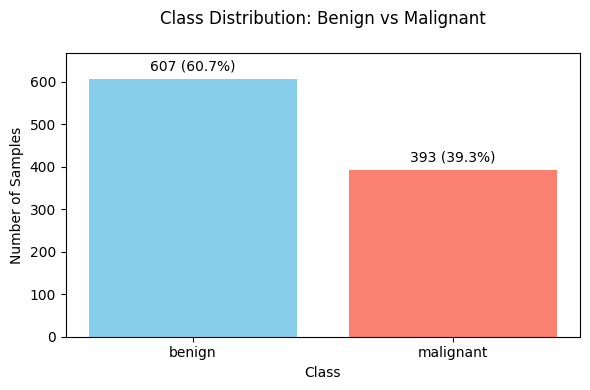

In [ ]:
class_counts = df['benign_malignant'].value_counts()
class_percentages = df['benign_malignant'].value_counts(normalize=True) * 100

plt.figure(figsize=(6, 4))
bars = plt.bar(class_counts.index, class_counts.values, color=['skyblue', 'salmon'])

y_max = class_counts.max()
plt.ylim(0, y_max * 1.10)

for bar, count, pct in zip(bars, class_counts.values, class_percentages.values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width() / 2, height + y_max * 0.02,
             f'{count} ({pct:.1f}%)', ha='center', va='bottom', fontsize=10)

plt.title('Class Distribution: Benign vs Malignant\n')
plt.xlabel('Class')
plt.ylabel('Number of Samples')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

# Splitting the data on three dataframes

In [ ]:
train_df, temp_df = train_test_split(
    df,
    test_size=0.30,
    stratify=df['benign_malignant'],
    random_state=42
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.50,
    stratify=temp_df['benign_malignant'],
    random_state=42
)

# Balance analysis

In [ ]:
def print_class_distribution(df, name):
    counts = df['benign_malignant'].value_counts()
    return counts

In [ ]:
def plot_class_distribution(counts, split_name):
    labels = counts.index.tolist()
    values = counts.values
    percentages = (counts / counts.sum()) * 100

    plt.figure(figsize=(6,4))
    bars = plt.bar(labels, values, color=['skyblue', 'salmon'])
    
    plt.ylim(0, max(values) * 1.1)

    for bar, value, pct in zip(bars, values, percentages):
        height = bar.get_height()
        plt.text(bar.get_x() + bar.get_width()/2, height + max(values)*0.01,
                 f"{value} ({pct:.1f}%)", ha='center', va='bottom', fontsize=10)

    plt.title(f'Class distribution - {split_name}')
    plt.ylabel('Number of samples')
    plt.xlabel('Class')
    plt.show()

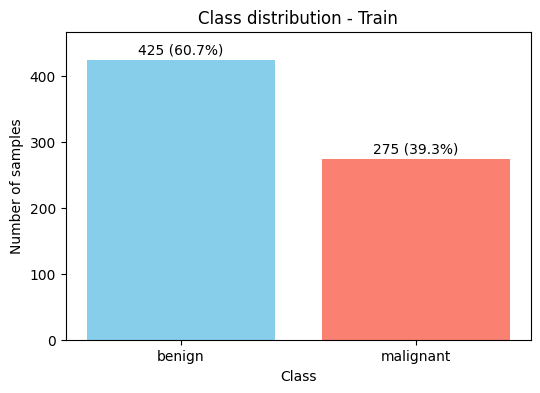

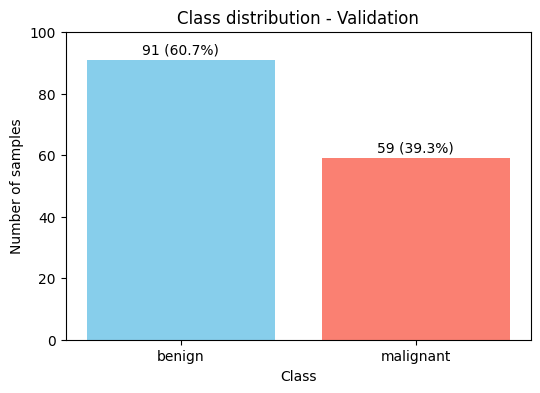

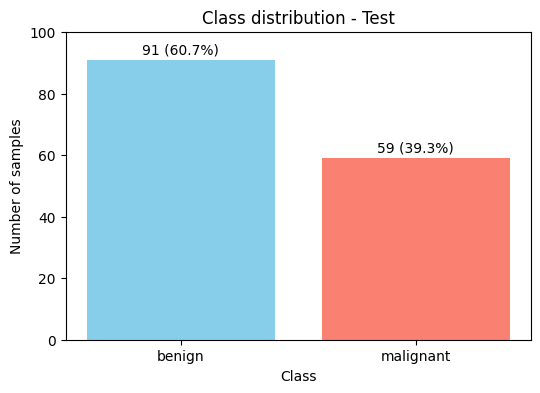

In [ ]:
train_counts = print_class_distribution(train_df, "Train")
val_counts = print_class_distribution(valid_df, "Validation")
test_counts = print_class_distribution(test_df, "Test")

train_count = len(train_df)
val_count = len(valid_df)
test_count = len(test_df)
total_count = train_count + val_count + test_count

plot_class_distribution(train_counts, "Train")
plot_class_distribution(val_counts, "Validation")
plot_class_distribution(test_counts, "Test")

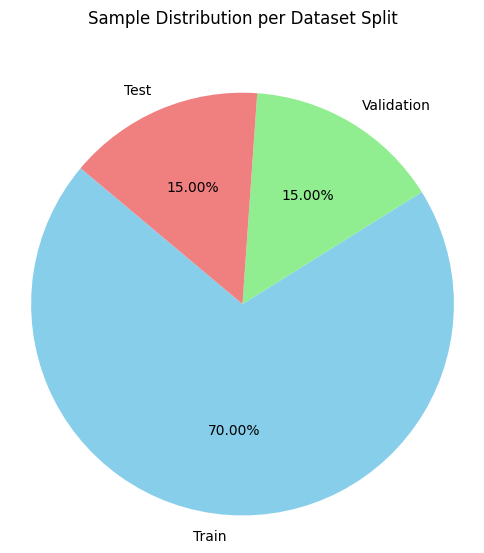


Total number of samples per split:
Train: 700
Validation: 150
Test: 150


In [ ]:
split_labels = ['Train', 'Validation', 'Test']
split_counts = [train_count, val_count, test_count]

plt.figure(figsize=(6, 6))
plt.pie(
    split_counts,
    labels=split_labels,
    autopct='%1.2f%%',
    colors=['skyblue', 'lightgreen', 'lightcoral'],
    startangle=140
)
plt.title('Sample Distribution per Dataset Split\n\n')
plt.axis('equal')
plt.show()

print("\nTotal number of samples per split:")
print(f"Train: {train_count}")
print(f"Validation: {val_count}")
print(f"Test: {test_count}")

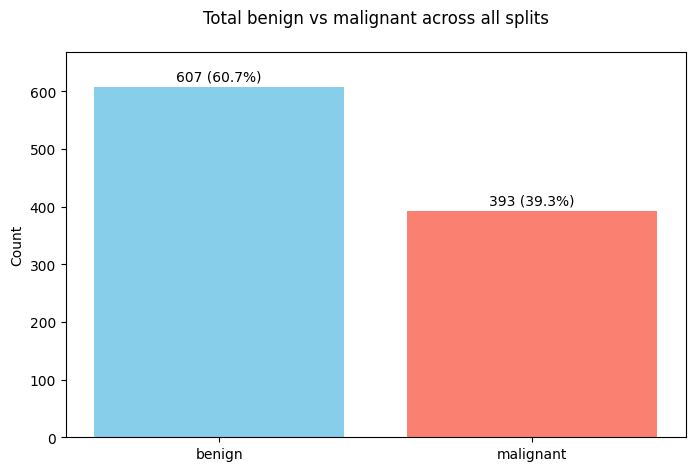

In [ ]:
total_counts = train_counts.add(val_counts, fill_value=0).add(test_counts, fill_value=0).astype(int)
total_percentages = (total_counts / total_counts.sum()) * 100

labels = total_counts.index.tolist()
counts = total_counts.values
percentages = total_percentages.values

plt.figure(figsize=(8, 5))
bars = plt.bar(labels, counts, color=['skyblue', 'salmon'])

plt.ylim(0, max(counts) * 1.1)

for bar, count, pct in zip(bars, counts, percentages):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height + max(counts)*0.01,
             f"{count} ({pct:.1f}%)",
             ha='center', va='bottom', fontsize=10)

plt.title("Total benign vs malignant across all splits\n")
plt.ylabel("Count")
plt.show()

# Saving csv files

In [10]:
train_df.to_csv('../datasets/ISIC24/train_metadata.csv', index=False, encoding='utf-8')
valid_df.to_csv('../datasets/ISIC24/validation_metadata.csv', index=False, encoding='utf-8')
test_df.to_csv('../datasets/ISIC24/test_metadata.csv', index=False, encoding='utf-8')